In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [49]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [59]:
df = df[['Annual_Income','Spending_Score']]
df

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [60]:
df.isna().sum()

Annual_Income     0
Spending_Score    0
dtype: int64

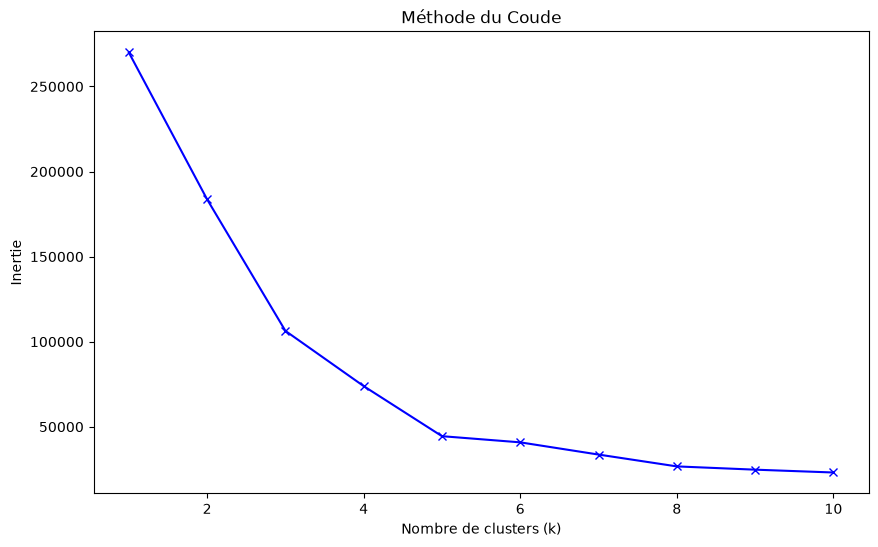

In [61]:


def plot_elbow_method(X, max_k=10):
    inertias = []
    K = range(1, max_k+1)
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
    
    # Visualisation basique
    plt.figure(figsize=(10, 6))
    plt.plot(K, inertias, 'bx-')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel('Inertie')
    plt.title('Méthode du Coude')

plot_elbow_method(df)


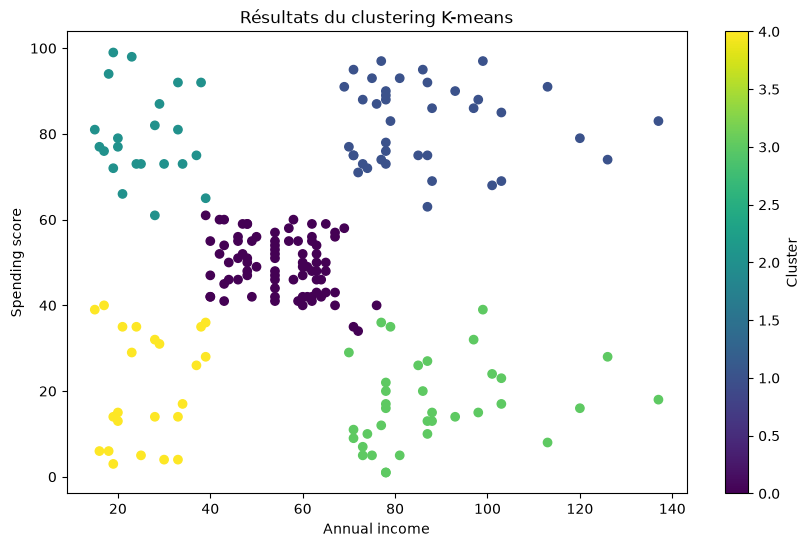

In [66]:
# Exemple basique de K-means
X = df
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)


# Visualisation des résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Annual_Income'], X['Spending_Score'], c=clusters, cmap='viridis')
plt.title("Résultats du clustering K-means")
plt.xlabel("Annual income")
plt.ylabel("Spending score")
plt.colorbar(label='Cluster')

Centres des clusters :
   Annual_Income  Spending_Score
0      55.296296       49.518519
1      86.538462       82.128205
2      25.727273       79.363636
3      88.200000       17.114286
4      26.304348       20.913043

Résumé des clusters :
         Annual_Income  Spending_Score        Age  Nb Clients
Cluster                                                      
0            55.296296       49.518519  42.716049          81
1            86.538462       82.128205  32.692308          39
2            25.727273       79.363636  25.272727          22
3            88.200000       17.114286  41.114286          35
4            26.304348       20.913043  45.217391          23


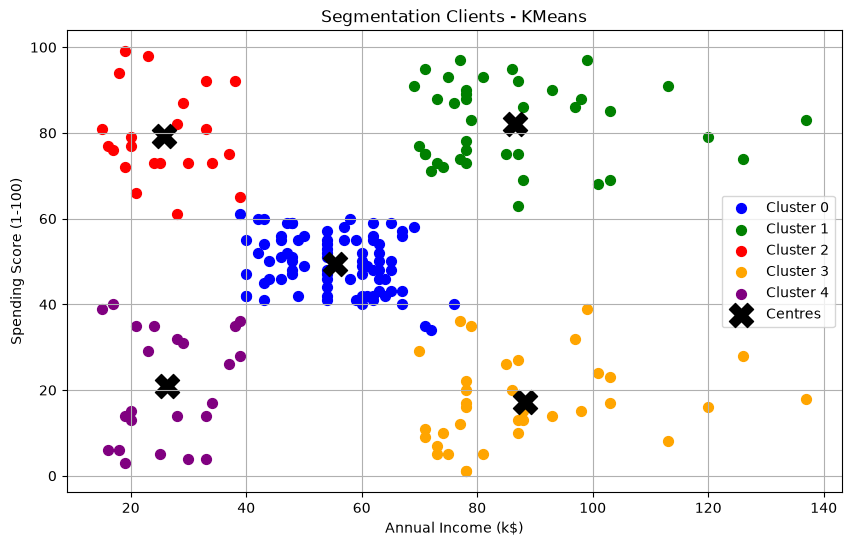

In [68]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv("Mall_Customers.csv")

# Variables utilisées pour le clustering
X = df[["Annual_Income", "Spending_Score"]]

# K-Means
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

# Centres des clusters
print("Centres des clusters :")
print(pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Annual_Income", "Spending_Score"]
))

# Statistiques par cluster
summary = df.groupby("Cluster").agg({
    "Annual_Income": "mean",
    "Spending_Score": "mean",
    "Age": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "Nb Clients"})

print("\nRésumé des clusters :")
print(summary)

# Visualisation
plt.figure(figsize=(10, 6))

colors = ["blue", "green", "red", "orange", "purple"]

for i in range(5):
    cluster = df[df["Cluster"] == i]
    plt.scatter(
        cluster["Annual_Income"],
        cluster["Spending_Score"],
        s=50,
        c=colors[i],
        label=f"Cluster {i}"
    )

# Centres
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c="black",
    marker="X",
    label="Centres"
)

plt.title("Segmentation Clients - KMeans")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()


df